# Integrated Gradients - Extended Bias Analysis

5 figures × 4 examples each = 20 examples total.
15 top words per example. Searching for bias in cities, gender, age, professions.

In [ ]:
import json
import joblib
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import re

BASE_DIR = Path(".")
MODEL_DIR = BASE_DIR / "models" / "bert_9classes_final"
PROCESSED_DIR = Path("..") / "data" / "processed"
FIGURES_DIR = Path("..") / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR.resolve()), local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR.resolve()), local_files_only=True)

le = joblib.load(MODEL_DIR / "label_encoder.joblib")
num_labels = len(le.classes_)

with open(MODEL_DIR / "label_mapping.json", "r", encoding="utf-8") as f:
    mapping_data = json.load(f)
id2label = {int(k): v for k, v in mapping_data["id2label"].items()}

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Model loaded. Device: {device}")

/Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:03<00:00, 54.65it/s, Materializing param=classifier.weight]                                      


Model loaded. Device: mps


In [2]:
# Load test data with predictions
df_test = pd.read_csv(PROCESSED_DIR / "test.csv")
mapping_df = pd.read_csv(PROCESSED_DIR / "label_to_supercategory_v1.csv")
label_to_supercat = dict(zip(mapping_df["label"], mapping_df["supercategory"]))
df_test["supercategory"] = df_test["label"].map(label_to_supercat)
df_test["y_true"] = le.transform(df_test["supercategory"])

def tokenize_fn(batch):
    return tokenizer(batch["resume_text"], padding="max_length", truncation=True, max_length=128)

test_dataset = Dataset.from_pandas(df_test[["resume_text", "y_true"]])
test_dataset = test_dataset.map(tokenize_fn, batched=True)
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "y_true"])

dataloader = DataLoader(test_dataset, batch_size=32)
all_preds = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Inference"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)

df_test["y_pred"] = all_preds
df_test["correct"] = df_test["y_true"] == df_test["y_pred"]
print(f"Test samples: {len(df_test)}, Accuracy: {df_test['correct'].mean():.4f}")

Inference: 100%|██████████| 173/173 [06:20<00:00,  2.20s/it]

Test samples: 5510, Accuracy: 0.6085


In [3]:
# IG setup
from captum.attr import LayerIntegratedGradients

def forward_func(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(forward_func, model.bert.embeddings)
print("IG initialized.")

IG initialized.


In [4]:
# Helper functions
TOP_K = 15  # 15 words per plot

def compute_ig(text, target_class, n_steps=25):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding="max_length")
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)
    attributions = lig.attribute(inputs=input_ids, additional_forward_args=(attention_mask,), target=int(target_class), n_steps=n_steps)
    scores = attributions.sum(dim=-1).squeeze().detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    attention = attention_mask[0].cpu().numpy()
    return [(tok, score) for tok, score, att in zip(tokens, scores, attention) if att == 1]

def merge_wordpieces(token_scores):
    merged = []
    current_word, current_score = "", 0.0
    for tok, score in token_scores:
        if tok.startswith("##"):
            current_word += tok[2:]
            current_score += score
        else:
            if current_word: merged.append((current_word, current_score))
            current_word, current_score = tok, score
    if current_word: merged.append((current_word, current_score))
    return merged

def clean_filter(word_scores, min_len=3):
    special = {"[CLS]", "[SEP]", "[PAD]", "[UNK]", "[MASK]"}
    year_re = re.compile(r"^\d{4}$")
    garbage_re = re.compile(r"^[\W\d_]+$")
    stops = {"the", "and", "for", "with", "from", "that", "this", "are", "was", "were", "have", "has", "been"}
    return [(w, s) for w, s in word_scores if w.upper() not in special and not year_re.match(w) and not garbage_re.match(w) and len(w) >= min_len and w.lower() not in stops]

def get_top_attr(text, target_class, top_k=TOP_K, n_steps=25):
    raw = compute_ig(text, target_class, n_steps)
    merged = merge_wordpieces(raw)
    cleaned = clean_filter(merged)
    return sorted(cleaned, key=lambda x: abs(x[1]), reverse=True)[:top_k]

def plot_bar(word_scores, title, ax):
    if not word_scores:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
        ax.set_title(title, fontsize=9, fontweight="bold")
        return
    words = [w for w,_ in word_scores]
    scores = [s for _,s in word_scores]
    colors = ["#2ecc71" if s > 0 else "#e74c3c" for s in scores]
    y_pos = np.arange(len(words))
    ax.barh(y_pos, scores, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=7)
    ax.invert_yaxis()
    ax.axvline(x=0, color="black", lw=0.5)
    ax.set_title(title, fontsize=8, fontweight="bold")

print("Helpers ready.")

Helpers ready.


In [5]:
# Helper to find example
used_indices = set()

def find_example(df_filter, example_type, extra_info=None):
    """Find first unused example matching filter"""
    df_filt = df_filter[~df_filter.index.isin(used_indices)]
    if len(df_filt) == 0:
        return None
    row = df_filt.iloc[0]
    idx = df_filt.index[0]
    used_indices.add(idx)
    ex = {
        "idx": idx,
        "type": example_type,
        "true_class": id2label[row["y_true"]],
        "pred_class": id2label[row["y_pred"]],
        "correct": row["correct"],
        "city": row.get("city_group", "N/A"),
        "gender": row.get("gender", "N/A"),
        "age": row.get("age_group", "N/A")
    }
    if extra_info:
        ex["extra"] = extra_info
    return ex

def make_title(ex):
    """Create subplot title"""
    status = "✓" if ex["correct"] else "✗"
    info_parts = [ex["type"]]
    if ex.get("city") and ex["city"] != "N/A":
        info_parts.append(ex["city"])
    if ex.get("gender") and ex["gender"] != "N/A":
        info_parts.append(ex["gender"])
    if ex.get("age") and ex["age"] != "N/A" and ex["age"] != "Unknown":
        info_parts.append(ex["age"])
    info = ", ".join(info_parts)
    return f"{status} {ex['true_class']}\n→ {ex['pred_class']}\n[{info}]"

print("Example finder ready.")

Example finder ready.


In [6]:
# Define 5 figure configurations
# Each figure has 4 examples (2x2 grid)

small_cities = ["Пермь", "Воронеж", "Омск", "Красноярск", "Томск", "Ижевск", "Тверь"]

figure_configs = [
    {
        "name": "ig_figure1_cities_large_vs_small",
        "title": "Figure 1: Cities - Large vs Small",
        "examples": [
            ("moscow_correct", df_test[(df_test["city_group"]=="Москва") & df_test["correct"]]),
            ("moscow_error", df_test[(df_test["city_group"]=="Москва") & ~df_test["correct"]]),
            ("small_city_correct", df_test[(df_test["city_group"].isin(small_cities)) & df_test["correct"]]),
            ("small_city_error", df_test[(df_test["city_group"].isin(small_cities)) & ~df_test["correct"]]),
        ]
    },
    {
        "name": "ig_figure2_gender",
        "title": "Figure 2: Gender Bias Analysis",
        "examples": [
            ("male_correct", df_test[(df_test["gender"]=="Male") & df_test["correct"]]),
            ("male_error", df_test[(df_test["gender"]=="Male") & ~df_test["correct"]]),
            ("female_correct", df_test[(df_test["gender"]=="Female") & df_test["correct"]]),
            ("female_error", df_test[(df_test["gender"]=="Female") & ~df_test["correct"]]),
        ]
    },
    {
        "name": "ig_figure3_age",
        "title": "Figure 3: Age Group Bias Analysis",
        "examples": [
            ("age_22_25_error", df_test[(df_test["age_group"]=="22–25") & ~df_test["correct"]]),
            ("age_36_50_error", df_test[(df_test["age_group"]=="36–50") & ~df_test["correct"]]),
            ("age_50plus_error", df_test[(df_test["age_group"]=="50+") & ~df_test["correct"]]),
            ("age_young_error", df_test[(df_test["age_group"].isin(["<18", "18–21"])) & ~df_test["correct"]]),
        ]
    },
    {
        "name": "ig_figure4_professions",
        "title": "Figure 4: Profession Misclassification",
        "examples": [
            ("backend_error", df_test[(df_test["y_true"]==le.transform(["backend_general_dev"])[0]) & ~df_test["correct"]]),
            ("frontend_error", df_test[(df_test["y_true"]==le.transform(["web_frontend"])[0]) & ~df_test["correct"]]),
            ("sysadmin_error", df_test[(df_test["y_true"]==le.transform(["sysadmin_devops_network"])[0]) & ~df_test["correct"]]),
            ("support_error", df_test[(df_test["y_true"]==le.transform(["tech_support_helpdesk"])[0]) & ~df_test["correct"]]),
        ]
    },
    {
        "name": "ig_figure5_cities_regions",
        "title": "Figure 5: Regional Cities Errors",
        "examples": [
            ("spb_error", df_test[(df_test["city_group"]=="Санкт-Петербург") & ~df_test["correct"]]),
            ("ekb_error", df_test[(df_test["city_group"]=="Екатеринбург") & ~df_test["correct"]]),
            ("kazan_error", df_test[(df_test["city_group"]=="Казань") & ~df_test["correct"]]),
            ("other_error", df_test[(df_test["city_group"]=="Other") & ~df_test["correct"]]),
        ]
    },
]

print(f"Defined {len(figure_configs)} figures with 4 examples each = {len(figure_configs)*4} total examples")

Defined 5 figures with 4 examples each = 20 total examples


Figures:   0%|          | 0/5 [00:00<?, ?it/s]

Saved: ../figures/ig_figure1_cities_large_vs_small.png


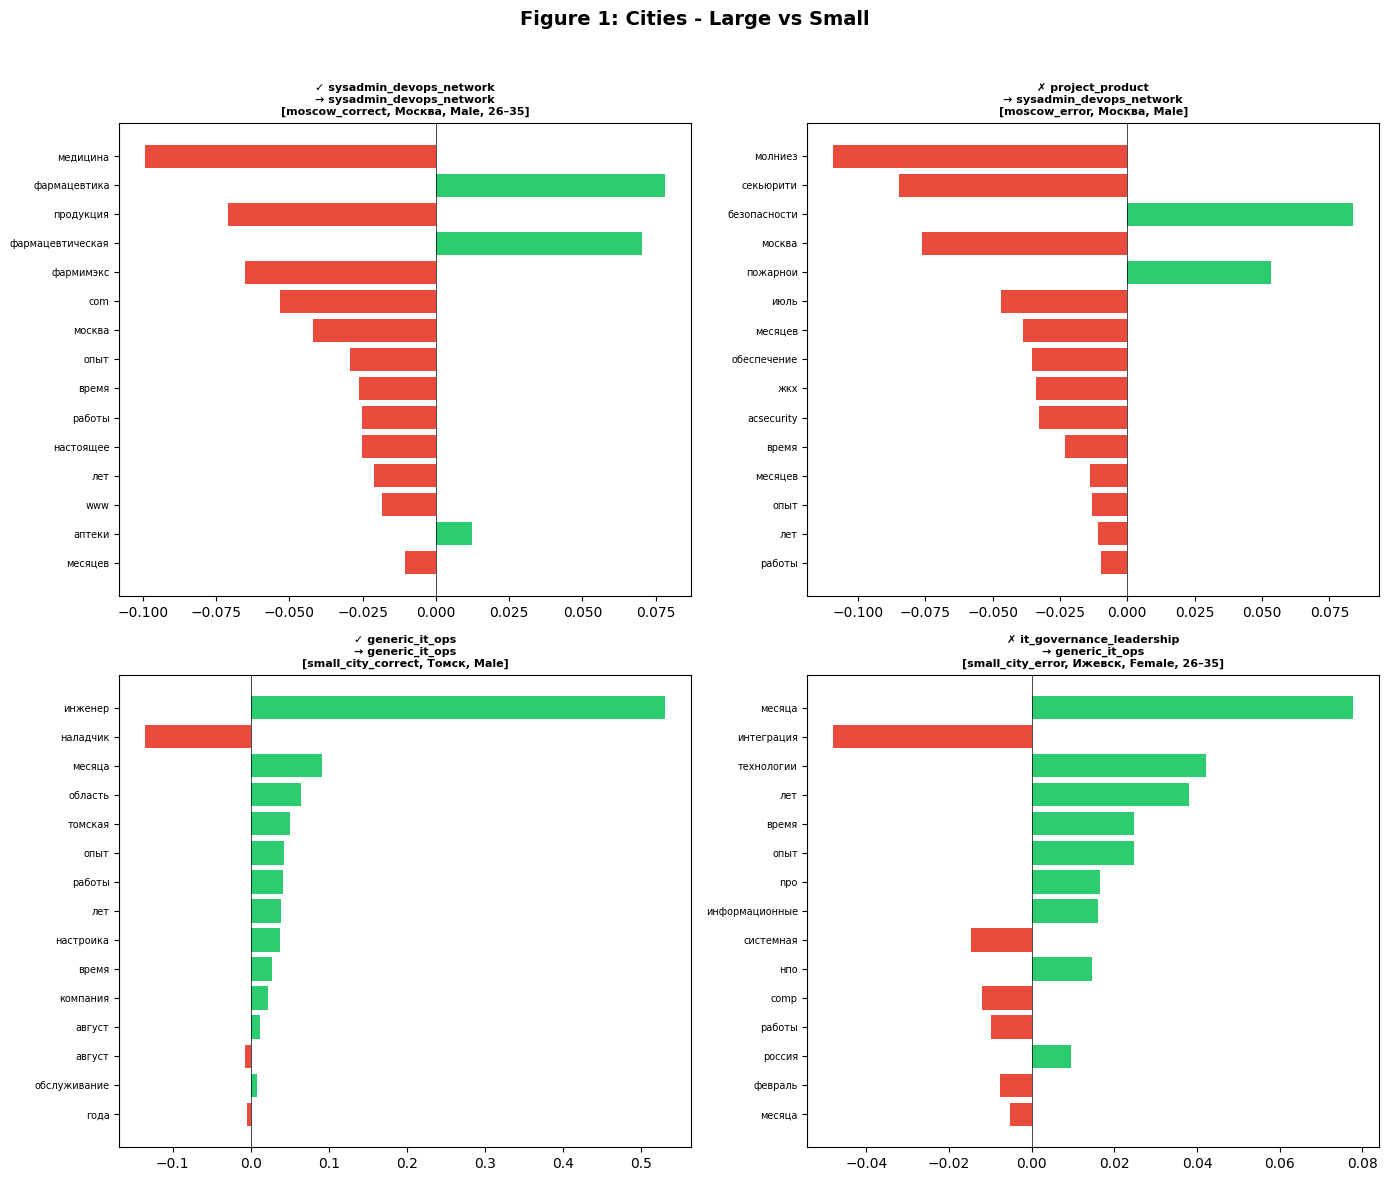

Figures:  20%|██        | 1/5 [00:22<01:28, 22.22s/it]

Saved: ../figures/ig_figure2_gender.png


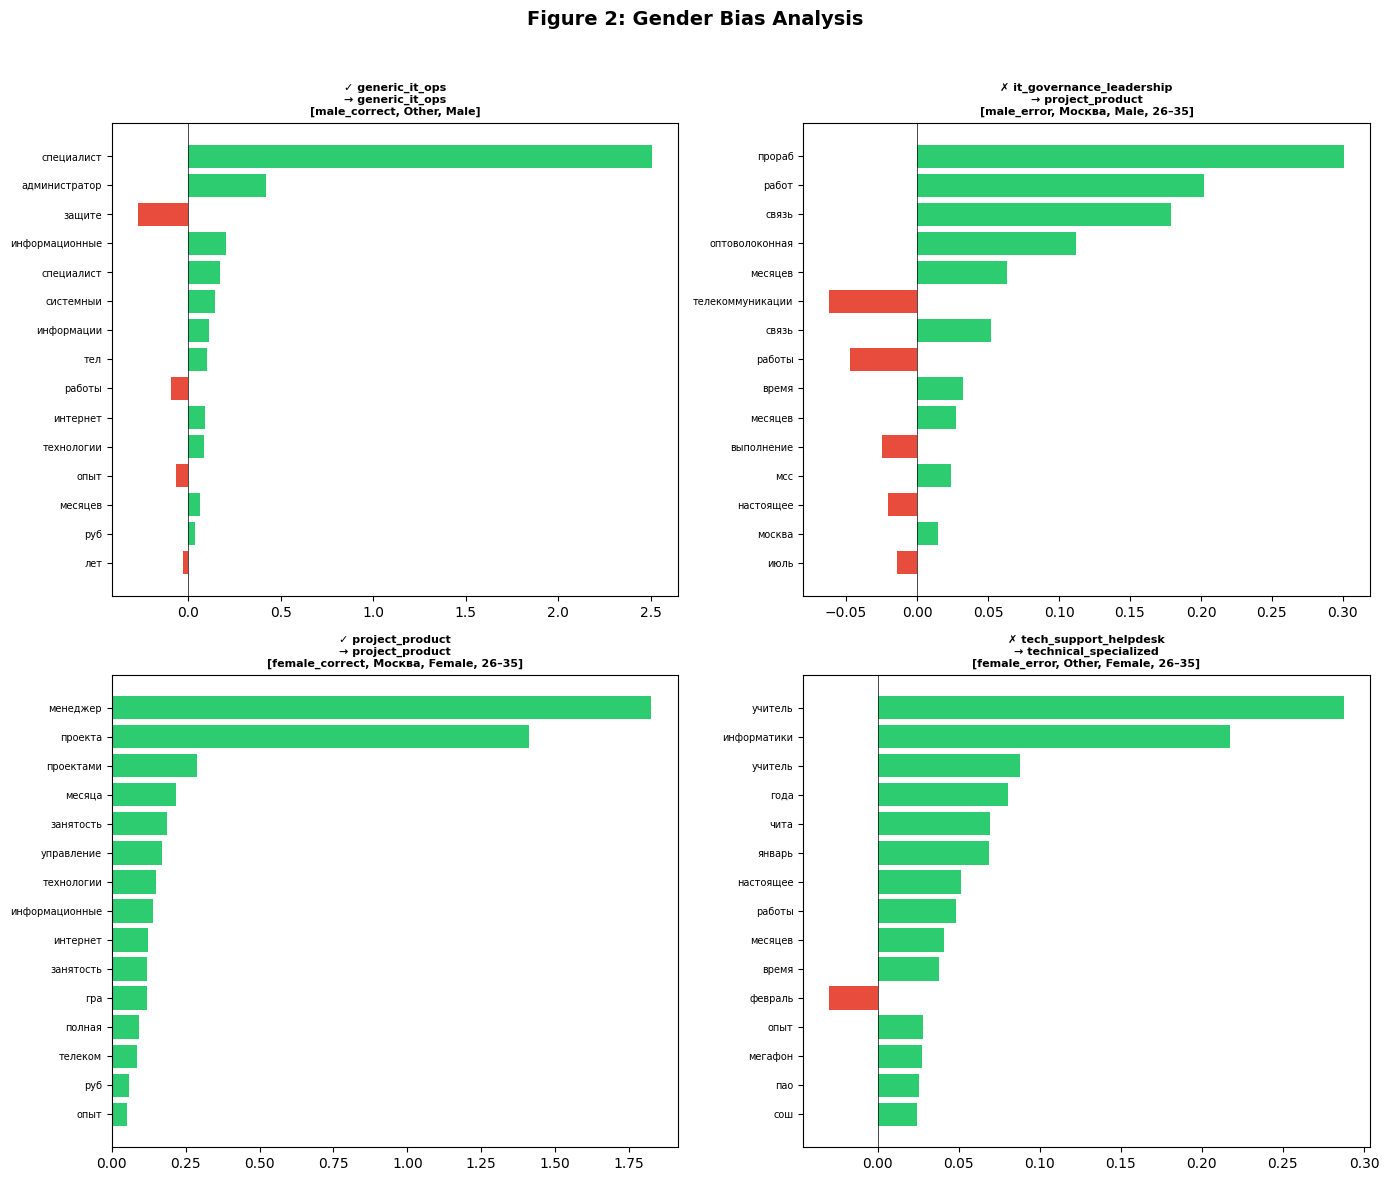

Figures:  40%|████      | 2/5 [00:44<01:05, 21.98s/it]

Saved: ../figures/ig_figure3_age.png


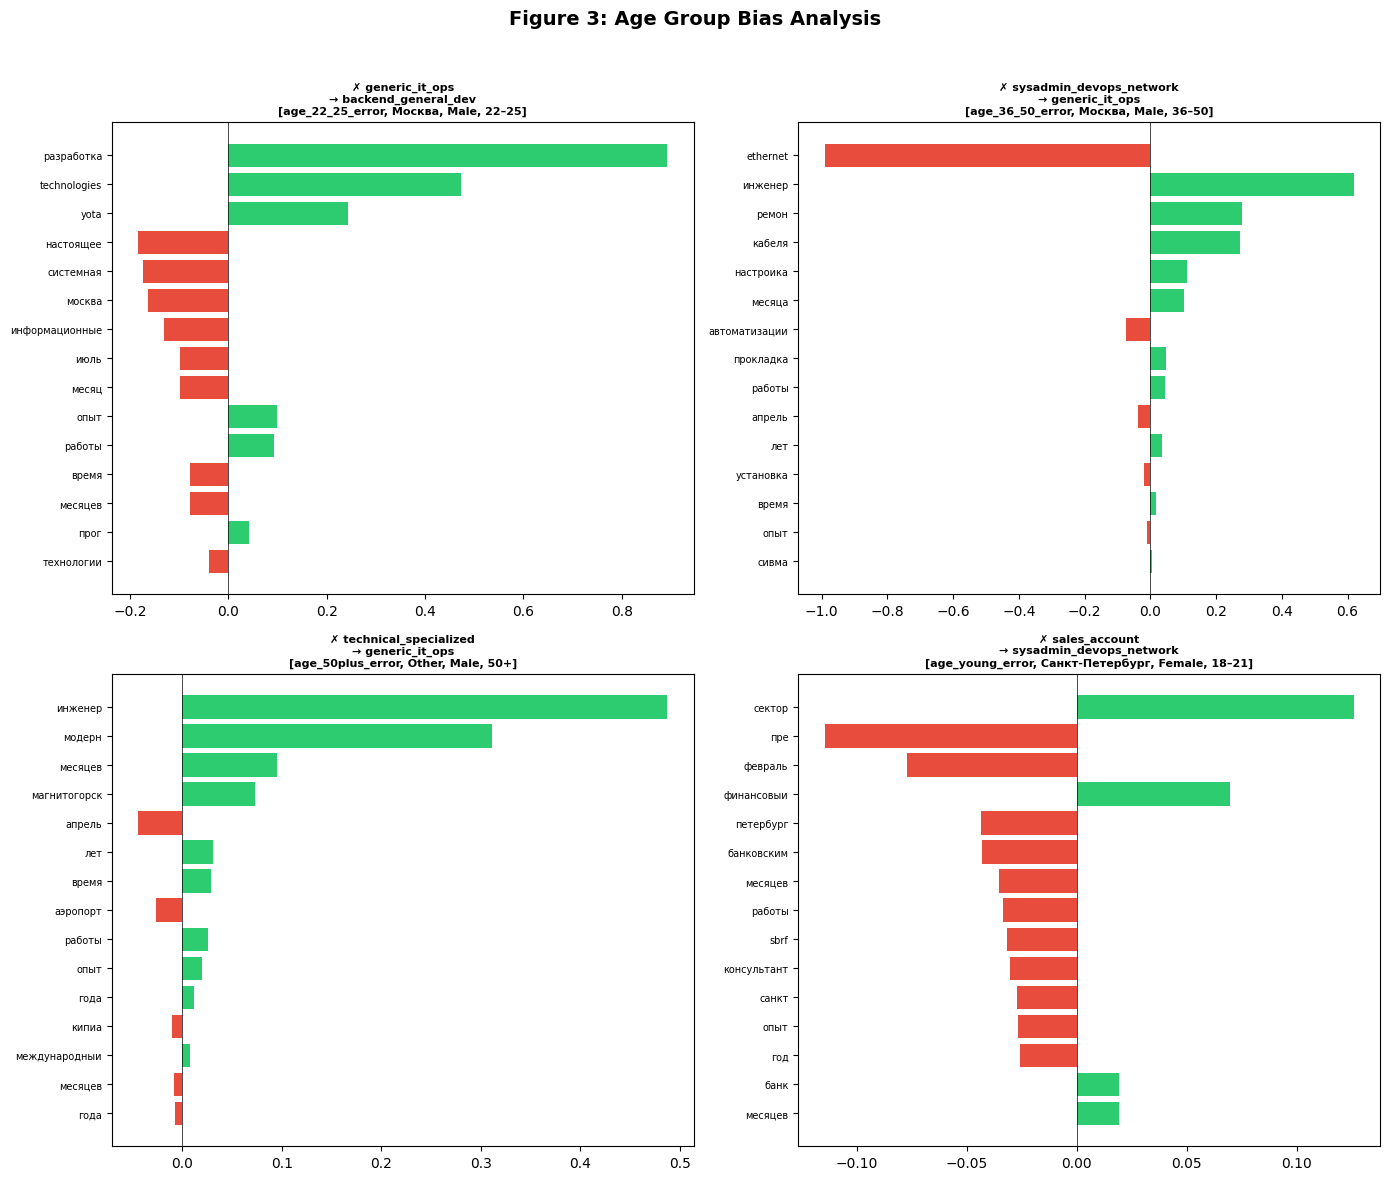

Figures:  60%|██████    | 3/5 [01:03<00:41, 20.77s/it]

Saved: ../figures/ig_figure4_professions.png


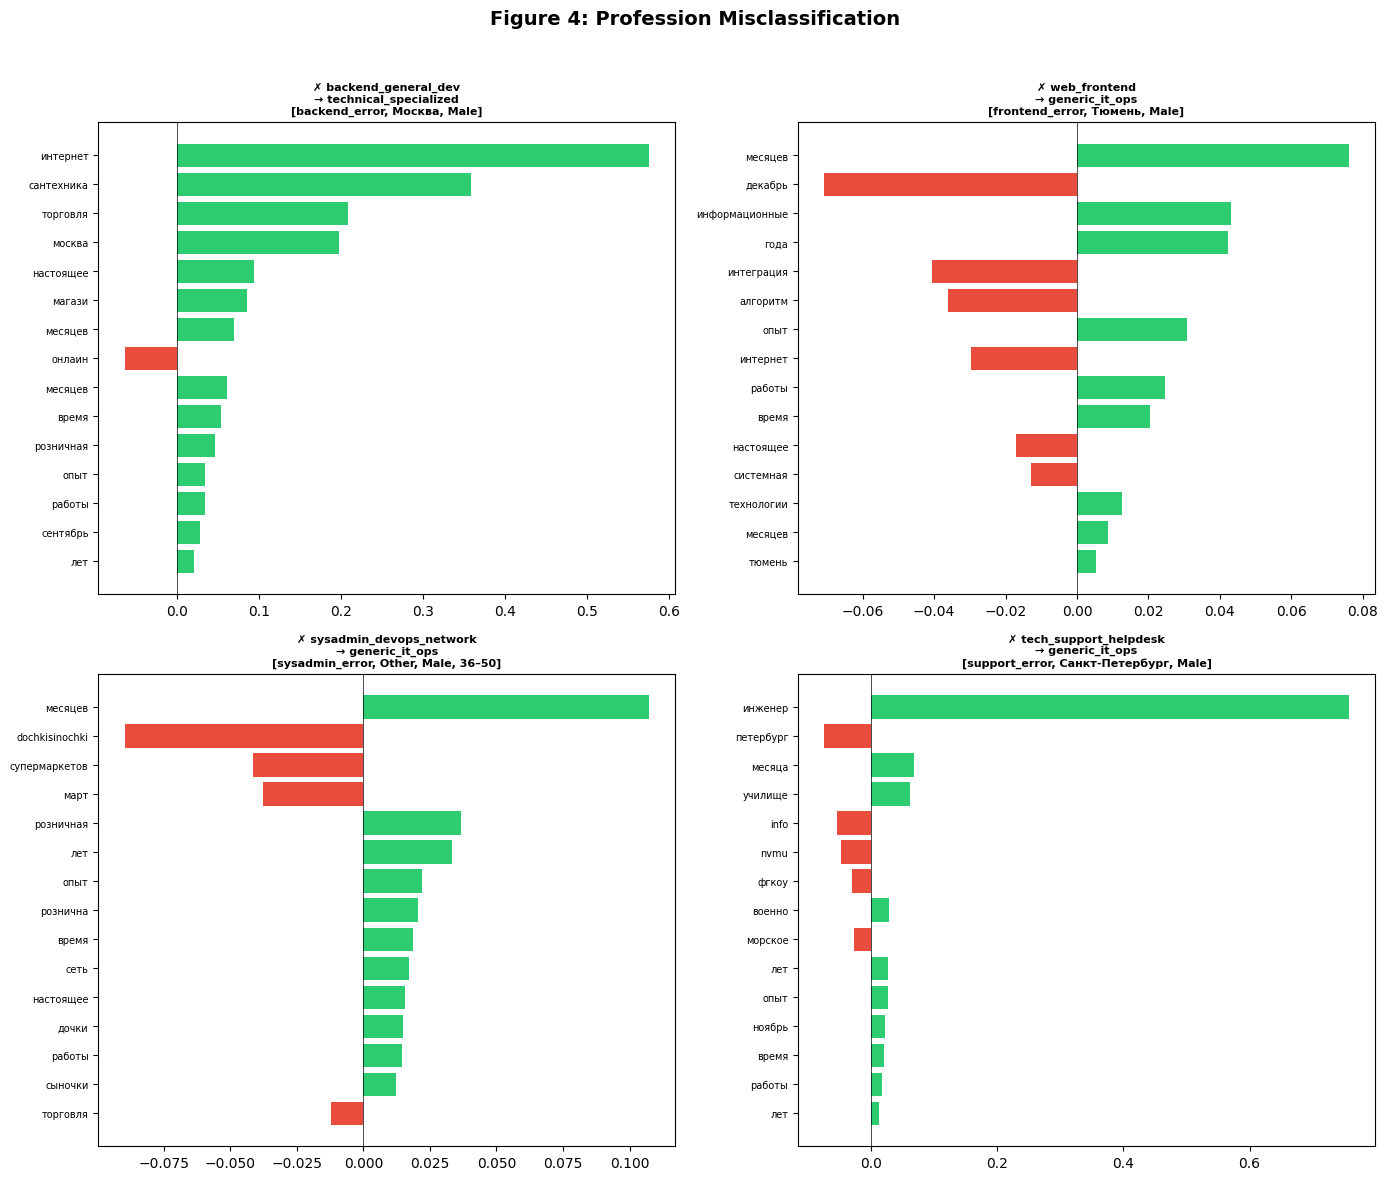

Figures:  80%|████████  | 4/5 [01:23<00:20, 20.60s/it]

Saved: ../figures/ig_figure5_cities_regions.png


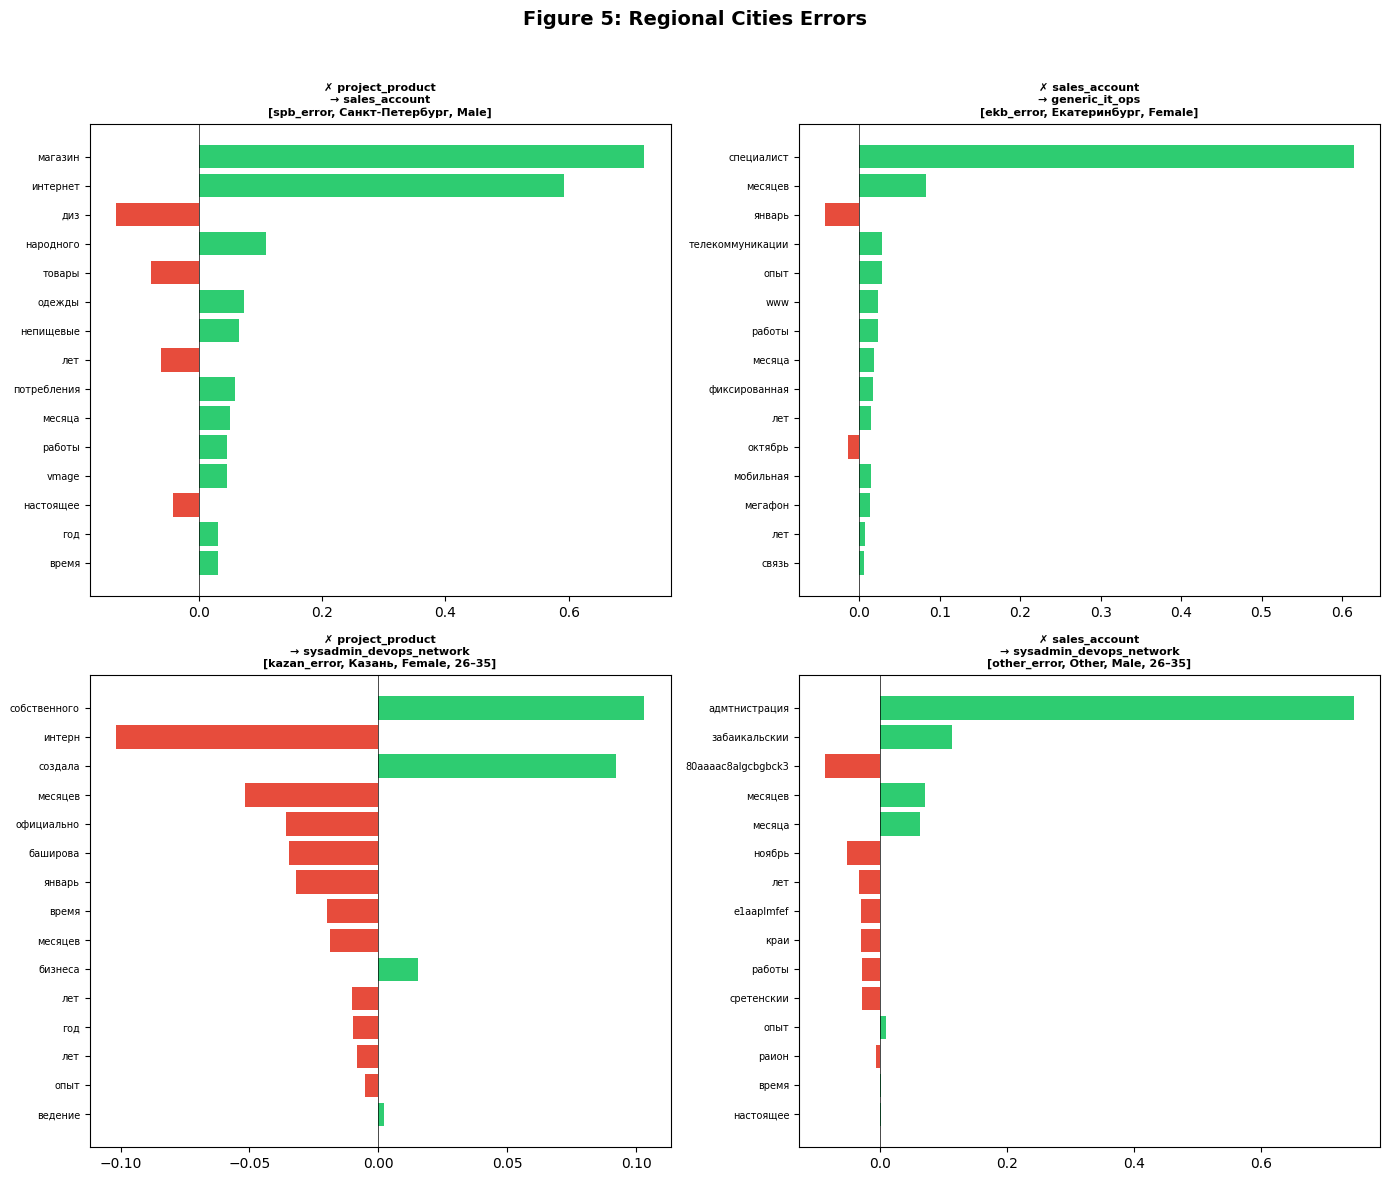

Figures: 100%|██████████| 5/5 [01:46<00:00, 21.28s/it]


In [7]:
# Generate all 5 figures
all_results = []

for fig_config in tqdm(figure_configs, desc="Figures"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    fig_results = []
    
    for i, (ex_type, df_filter) in enumerate(fig_config["examples"]):
        ex = find_example(df_filter, ex_type)
        
        if ex is None:
            axes[i].text(0.5, 0.5, f"No example found for {ex_type}", ha="center", va="center")
            axes[i].set_title(ex_type)
            continue
        
        row = df_test.loc[ex["idx"]]
        top_words = get_top_attr(row["resume_text"], row["y_pred"], top_k=TOP_K)
        
        title = make_title(ex)
        plot_bar(top_words, title, axes[i])
        
        fig_results.append({"example": ex, "top_words": top_words})
    
    plt.suptitle(fig_config["title"], fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save figure
    save_path = FIGURES_DIR / f"{fig_config['name']}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
    
    all_results.append({"figure": fig_config["name"], "results": fig_results})

In [8]:
# Save summary CSV
summary_rows = []
for fig_data in all_results:
    for r in fig_data["results"]:
        ex = r["example"]
        pos = [w for w,s in r["top_words"] if s > 0][:5]
        neg = [w for w,s in r["top_words"] if s < 0][:5]
        summary_rows.append({
            "figure": fig_data["figure"],
            "type": ex["type"],
            "correct": ex["correct"],
            "true_class": ex["true_class"],
            "pred_class": ex["pred_class"],
            "city": ex.get("city", ""),
            "gender": ex.get("gender", ""),
            "age": ex.get("age", ""),
            "top_positive": ", ".join(pos),
            "top_negative": ", ".join(neg)
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FIGURES_DIR / "integrated_gradients_summary.csv", index=False)
print(f"Summary saved with {len(summary_df)} examples")
summary_df

Summary saved with 20 examples


,figure,type,correct,true_class,pred_class,city,gender,age,top_positive,top_negative
0,ig_figure1_cities_large_vs_small,moscow_correct,True,sysadmin_devops_network,sysadmin_devops_network,Москва,Male,26–35,"фармацевтика, фармацевтическая, аптеки","медицина, продукция, фармимэкс, com, москва"
1,ig_figure1_cities_large_vs_small,moscow_error,False,project_product,sysadmin_devops_network,Москва,Male,Unknown,"безопасности, пожарнои","молниез, секьюрити, москва, июль, месяцев"
2,ig_figure1_cities_large_vs_small,small_city_correct,True,generic_it_ops,generic_it_ops,Томск,Male,Unknown,"инженер, месяца, область, томская, опыт","наладчик, август, года"
3,ig_figure1_cities_large_vs_small,small_city_error,False,it_governance_leadership,generic_it_ops,Ижевск,Female,26–35,"месяца, технологии, лет, время, опыт","интеграция, системная, comp, работы, февраль"
4,ig_figure2_gender,male_correct,True,generic_it_ops,generic_it_ops,Other,Male,Unknown,"специалист, администратор, информационные, спе...","защите, работы, опыт, лет"
5,ig_figure2_gender,male_error,False,it_governance_leadership,project_product,Москва,Male,26–35,"прораб, работ, связь, оптоволоконная, месяцев","телекоммуникации, работы, выполнение, настояще..."
6,ig_figure2_gender,female_correct,True,project_product,project_product,Москва,Female,26–35,"менеджер, проекта, проектами, месяца, занятость",
7,ig_figure2_gender,female_error,False,tech_support_helpdesk,technical_specialized,Other,Female,26–35,"учитель, информатики, учитель, года, чита",февраль
8,ig_figure3_age,age_22_25_error,False,generic_it_ops,backend_general_dev,Москва,Male,22–25,"разработка, technologies, yota, опыт, работы","настоящее, системная, москва, информационные, ..."
9,ig_figure3_age,age_36_50_error,False,sysadmin_devops_network,generic_it_ops,Москва,Male,36–50,"инженер, ремон, кабеля, настроика, месяца","ethernet, автоматизации, апрель, установка, опыт"


In [14]:
# Bias analysis summary
print("\n" + "="*60)
print("BIAS ANALYSIS SUMMARY")
print("="*60)

# Check for city names in attributions
city_words = ["москва", "петербург", "спб", "екатеринбург", "казань", "новосибирск", "магнитогорск", "чита", "забайкальский", "томск", "ижевск", "воронеж", "омск"]
gender_words = ["мужчина", "женщина", "мужской", "женский", "он", "она"]
age_words = ["лет", "года", "год", "молодой", "опыт"]

bias_found = []
for fig_data in all_results:
    for r in fig_data["results"]:
        for w, s in r["top_words"]:
            w_lower = w.lower()
            if any(c in w_lower for c in city_words):
                bias_found.append(("CITY", w, s, r["example"]["type"]))

if bias_found:
    print("\nPotential bias indicators found in attributions:")
    for bias_type, word, score, ex_type in bias_found:
        direction = "POSITIVE" if score > 0 else "NEGATIVE"
        print(f"  [{bias_type}] '{word}' ({direction}, score={score:.4f}) in {ex_type}")
else:
    print("\nNo obvious city/gender words found in top attributions.")
    print("Bias may still exist in more subtle patterns.")

print("\n" + "="*60)


BIAS ANALYSIS SUMMARY

Potential bias indicators found in attributions:
  [CITY] 'москва' (NEGATIVE, score=-0.0418) in moscow_correct
  [CITY] 'москва' (NEGATIVE, score=-0.0762) in moscow_error
  [CITY] 'томская' (POSITIVE, score=0.0504) in small_city_correct
  [CITY] 'москва' (POSITIVE, score=0.0151) in male_error
  [CITY] 'чита' (POSITIVE, score=0.0690) in female_error
  [CITY] 'москва' (NEGATIVE, score=-0.1639) in age_22_25_error
  [CITY] 'магнитогорск' (POSITIVE, score=0.0731) in age_50plus_error
  [CITY] 'петербург' (NEGATIVE, score=-0.0434) in age_young_error
  [CITY] 'москва' (POSITIVE, score=0.1974) in backend_error
  [CITY] 'петербург' (NEGATIVE, score=-0.0743) in support_error



In [15]:
# Define target words for each bias type
city_words = ["москва", "петербург", "спб", "казань", "екатеринбург", 
              "новосибирск", "томск", "ижевск", "магнитогорск", "воронеж",
              "краснодар", "омск", "пермь", "самара", "уфа", "челябинск",
              "санкт", "нижний", "ростов", "красноярск", "забайкальский"]

print("Collecting word attributions across professions...")
print(f"City words to track: {len(city_words)}")

City words to track: 21


In [16]:
# compute IG for sample with city words

def extract_word_attribution(text, target_class, target_words, n_steps=25):
    """Extract attribution scores for specific words from a text"""
    raw = compute_ig(text, target_class, n_steps)
    merged = merge_wordpieces(raw)
    
    results = {}
    for word, score in merged:
        word_lower = word.lower()
        for target in target_words:
            if target in word_lower or word_lower in target:
                if target not in results:
                    results[target] = []
                results[target].append(score)
    return results

# Sample 3 examples per profession that contain city names
city_attr_by_prof = {prof: {} for prof in id2label.values()}

for prof_id, prof_name in tqdm(id2label.items(), desc="Professions"):
    # Get examples for this profession
    df_prof = df_test[df_test["y_true"] == prof_id].head(5)
    
    for _, row in df_prof.iterrows():
        text_lower = row["resume_text"].lower()
        # Check if any city word is in text
        has_city = any(cw in text_lower for cw in city_words)
        if has_city:
            attrs = extract_word_attribution(row["resume_text"], row["y_pred"], city_words)
            for city, scores in attrs.items():
                if city not in city_attr_by_prof[prof_name]:
                    city_attr_by_prof[prof_name][city] = []
                city_attr_by_prof[prof_name][city].extend(scores)

print("Done collecting city attributions!")

Professions: 100%|██████████| 9/9 [02:53<00:00, 19.33s/it]

Done collecting city attributions!


Saved: ig_figure6_city_words.png


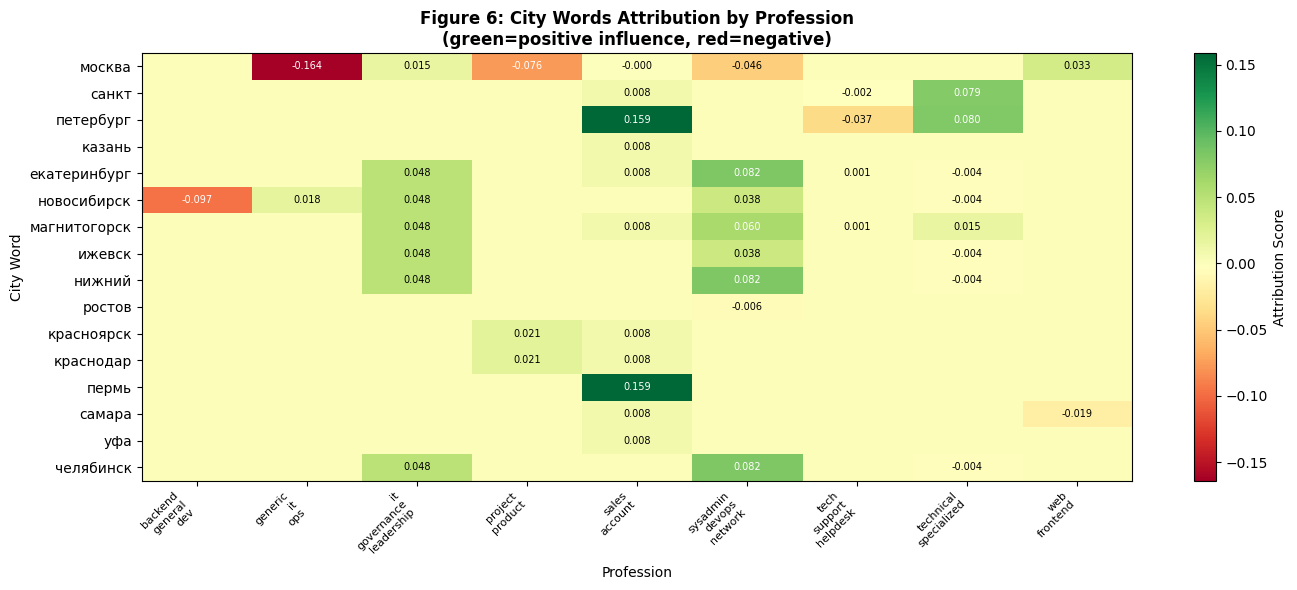

In [24]:
# figure 6: city words attribution

# Aggregate: mean attribution per city per profession
top_cities = ["москва", "санкт", "петербург", "казань", "екатеринбург", "новосибирск", "магнитогорск", "ижевск", "нижний", "ростов", "красноярск", "краснодар", "пермь", "самара", "уфа", "челябинск"]

# Build matrix
profs = list(id2label.values())
data_matrix = []

for city in top_cities:
    row = []
    for prof in profs:
        scores = city_attr_by_prof[prof].get(city, [])
        mean_score = np.mean(scores) if scores else 0
        row.append(mean_score)
    data_matrix.append(row)

data_matrix = np.array(data_matrix)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(data_matrix, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(profs)))
ax.set_xticklabels([p.replace("_", "\n") for p in profs], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(top_cities)))
ax.set_yticklabels(top_cities, fontsize=10)

# Add values
for i in range(len(top_cities)):
    for j in range(len(profs)):
        val = data_matrix[i, j]
        if val != 0:
            color = "white" if abs(val) > 0.05 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, label="Attribution Score")
plt.title("Figure 6: City Words Attribution by Profession\n(green=positive influence, red=negative)", fontsize=12, fontweight="bold")
plt.xlabel("Profession")
plt.ylabel("City Word")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ig_figure6_city_words.png", dpi=150, bbox_inches="tight")
print("Saved: ig_figure6_city_words.png")
plt.show()

In [21]:
# figure 7: gender-related words

# Gender-related words that might appear in resumes
gender_words = ["мужчина", "женщина", "муж", "жена", "отец", "мать",
                "армия", "военный", "служба", "декрет", "декретный"]

gender_attr_by_prof = {prof: {} for prof in id2label.values()}

for prof_id, prof_name in tqdm(id2label.items(), desc="Gender words"):
    df_prof = df_test[df_test["y_true"] == prof_id].head(10)
    
    for _, row in df_prof.iterrows():
        text_lower = row["resume_text"].lower()
        has_gender = any(gw in text_lower for gw in gender_words)
        if has_gender:
            attrs = extract_word_attribution(row["resume_text"], row["y_pred"], gender_words)
            for gw, scores in attrs.items():
                if gw not in gender_attr_by_prof[prof_name]:
                    gender_attr_by_prof[prof_name][gw] = []
                gender_attr_by_prof[prof_name][gw].extend(scores)

# Plot
found_gender_words = set()
for prof_data in gender_attr_by_prof.values():
    found_gender_words.update(prof_data.keys())
found_gender_words = sorted(found_gender_words)

if found_gender_words:
    data_matrix_g = []
    for gw in found_gender_words:
        row = []
        for prof in profs:
            scores = gender_attr_by_prof[prof].get(gw, [])
            mean_score = np.mean(scores) if scores else 0
            row.append(mean_score)
        data_matrix_g.append(row)
    data_matrix_g = np.array(data_matrix_g)

    fig, ax = plt.subplots(figsize=(14, max(4, len(found_gender_words)*0.5)))
    im = ax.imshow(data_matrix_g, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(profs)))
    ax.set_xticklabels([p.replace("_", "\n") for p in profs], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(found_gender_words)))
    ax.set_yticklabels(found_gender_words, fontsize=10)
    
    for i in range(len(found_gender_words)):
        for j in range(len(profs)):
            val = data_matrix_g[i, j]
            if val != 0:
                color = "white" if abs(val) > 0.05 else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)
    
    plt.colorbar(im, label="Attribution Score")
    plt.title("Figure 7: Gender-Related Words Attribution by Profession", fontsize=12, fontweight="bold")
    plt.xlabel("Profession")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "ig_figure7_gender_words.png", dpi=150, bbox_inches="tight")
    print("Saved: ig_figure7_gender_words.png")
    plt.show()
else:
    print("No direct gender words found in sampled resumes.")
    print("Gender bias may be encoded indirectly (surnames, job titles, etc.)")

Gender words: 100%|██████████| 9/9 [00:45<00:00,  5.04s/it]

No direct gender words found in sampled resumes.
Gender bias may be encoded indirectly (surnames, job titles, etc.)


Age words: 100%|██████████| 9/9 [07:06<00:00, 47.33s/it]


Saved: ig_figure8_age_words.png


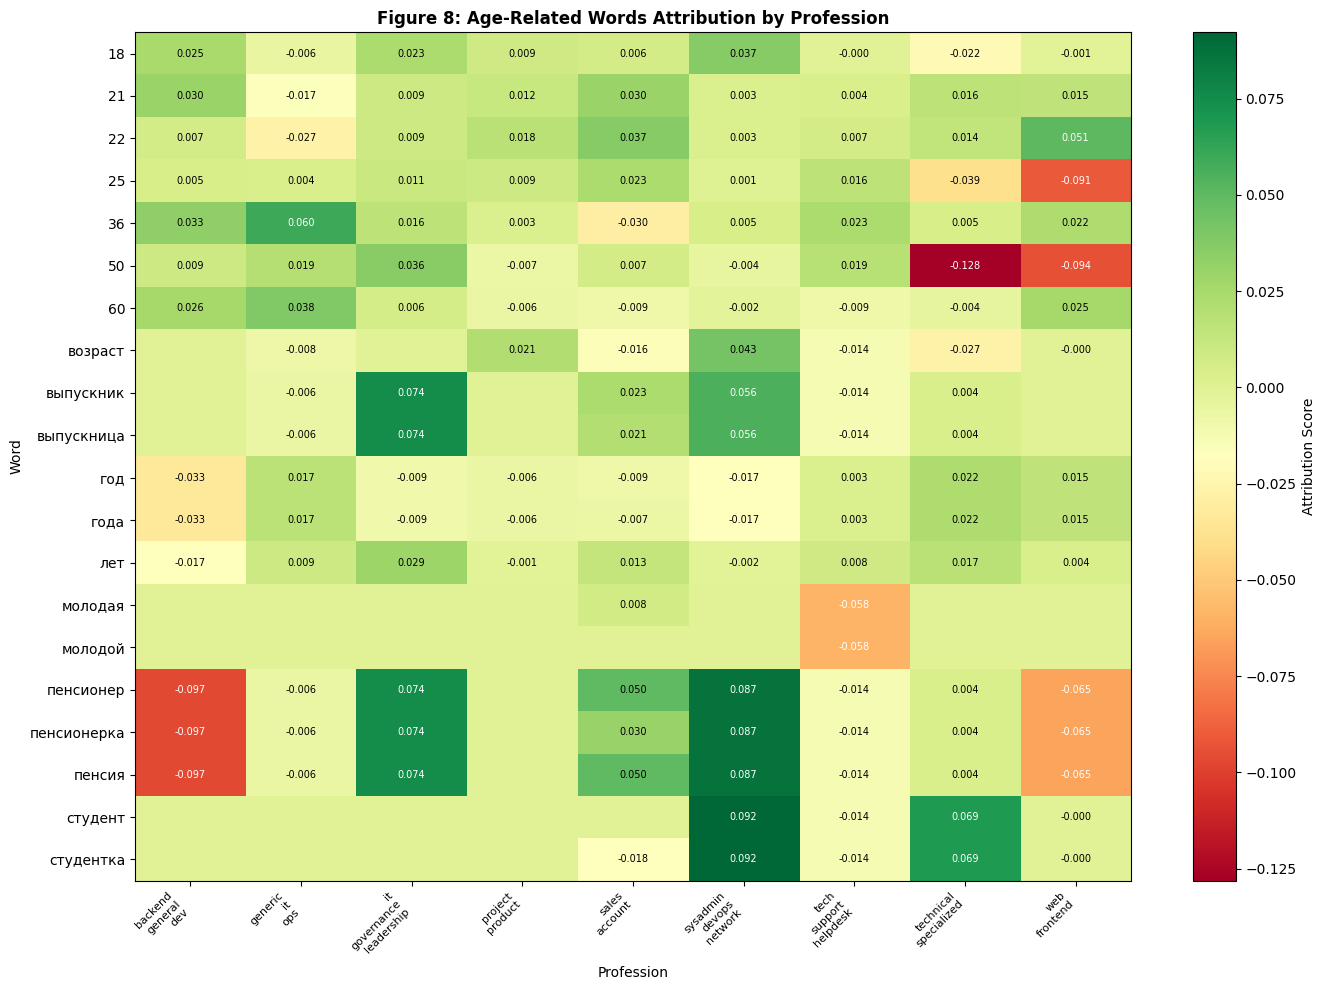

In [25]:
# figure 8: age-related words

age_words = ["лет", "года", "год", "возраст", "пенсия", "пенсионер", "пенсионерка",
             "молодой", "молодая", "студент", "студентка", "выпускник", "выпускница", "18", "21", "22", "25", "36", "50", "60"]

age_attr_by_prof = {prof: {} for prof in id2label.values()}

for prof_id, prof_name in tqdm(id2label.items(), desc="Age words"):
    df_prof = df_test[df_test["y_true"] == prof_id].head(10)
    
    for _, row in df_prof.iterrows():
        attrs = extract_word_attribution(row["resume_text"], row["y_pred"], age_words)
        for aw, scores in attrs.items():
            if aw not in age_attr_by_prof[prof_name]:
                age_attr_by_prof[prof_name][aw] = []
            age_attr_by_prof[prof_name][aw].extend(scores)

# Plot
found_age_words = set()
for prof_data in age_attr_by_prof.values():
    found_age_words.update(prof_data.keys())
found_age_words = sorted(found_age_words)

if found_age_words:
    data_matrix_a = []
    for aw in found_age_words:
        row = []
        for prof in profs:
            scores = age_attr_by_prof[prof].get(aw, [])
            mean_score = np.mean(scores) if scores else 0
            row.append(mean_score)
        data_matrix_a.append(row)
    data_matrix_a = np.array(data_matrix_a)

    fig, ax = plt.subplots(figsize=(14, max(4, len(found_age_words)*0.5)))
    im = ax.imshow(data_matrix_a, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(profs)))
    ax.set_xticklabels([p.replace("_", "\n") for p in profs], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(found_age_words)))
    ax.set_yticklabels(found_age_words, fontsize=10)
    
    for i in range(len(found_age_words)):
        for j in range(len(profs)):
            val = data_matrix_a[i, j]
            if val != 0:
                color = "white" if abs(val) > 0.05 else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)
    
    plt.colorbar(im, label="Attribution Score")
    plt.title("Figure 8: Age-Related Words Attribution by Profession", fontsize=12, fontweight="bold")
    plt.xlabel("Profession")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "ig_figure8_age_words.png", dpi=150, bbox_inches="tight")
    print("Saved: ig_figure8_age_words.png")
    plt.show()
else:
    print("No age words found.")